# **Acne Segmentation — SegFormer B2**

## **Imports**

In [1]:
import os
import random
import gc
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from transformers import SegformerForSemanticSegmentation

## **Configuration**

In [2]:
ROOT = "/kaggle/input/datasets/karmagames/acne04-v2/"

MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

# For a baseline experiment, which involves only augmentations
IMAGES_DIR = os.path.join(ROOT, "img_data/img_data")

# For a ROI experiment, which involves extraction of facial ROI region
# IMAGES_DIR = os.path.join(ROOT, "clean_roi/clean_roi")

# For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMAGES_DIR = os.path.join(ROOT, "images_acne_preprocess/images_acne_preprocess")


IMAGE_SIZE = 1024
BATCH_SIZE = 2
NUM_WORKERS = 2
NUM_EPOCHS = 40
SEED = 42
THRESHOLD = 0.5

MODEL_NAME = 'nvidia/segformer-b2-finetuned-ade-512-512'
CHECKPOINT_PATH = '/kaggle/working/best_segformer_acne.pt'

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print('Device:', device)

Device: cuda


## **Augmentations**

In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.8, 1.25), p=0.5):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(*self.gamma_range)
            return TF.adjust_gamma(img, gamma)
        return img


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(*self.radius_range)
            return TF.gaussian_blur(img, kernel_size=3, sigma=sigma)
        return img

## **Augmentations and Dataset**

In [4]:
class AcneSegDataset(Dataset):
    def __init__(self, image_paths, images_dir, masks_dir, image_size=1024, train=True, return_path=False):
        self.image_paths = image_paths
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.train = train
        self.return_path = return_path

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.08, hue=0.015),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])
        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.image_paths)

    def _get_image_path(self, img_item):
        img_item = Path(img_item)
        return img_item if img_item.exists() else self.images_dir / img_item.name

    def _get_mask_path(self, img_path):
        return self.masks_dir / f'{Path(img_path).stem}.png'

    def __getitem__(self, idx):
        img_path = self._get_image_path(self.image_paths[idx])
        mask_path = self._get_mask_path(img_path)

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        img = TF.to_pil_image(img)
        mask = TF.to_pil_image(mask)

        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        img = self.normalize(TF.to_tensor(img))
        mask = (TF.to_tensor(mask) > 0.5).float()

        if self.return_path:
            return img, mask, str(img_path)
        return img, mask

## **Preprare Data**

In [7]:
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_image_paths = []
for filename in sorted(os.listdir(IMAGES_DIR)):
    if Path(filename).suffix.lower() not in valid_exts:
        continue

    image_path = os.path.join(IMAGES_DIR, filename)
    mask_path = os.path.join(MASKS_DIR, f"{Path(filename).stem}.png")

    if os.path.exists(mask_path):
        all_image_paths.append(image_path)

print(f"Found {len(all_image_paths)} image-mask pairs")

train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=SEED,
    shuffle=True,
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


Found 1204 image-mask pairs
Train: 963
Validation: 120
Test: 121


In [8]:
train_ds = AcneSegDataset(train_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=True)
val_ds = AcneSegDataset(val_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=False)
test_ds = AcneSegDataset(test_paths, IMAGES_DIR, MASKS_DIR, image_size=IMAGE_SIZE, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

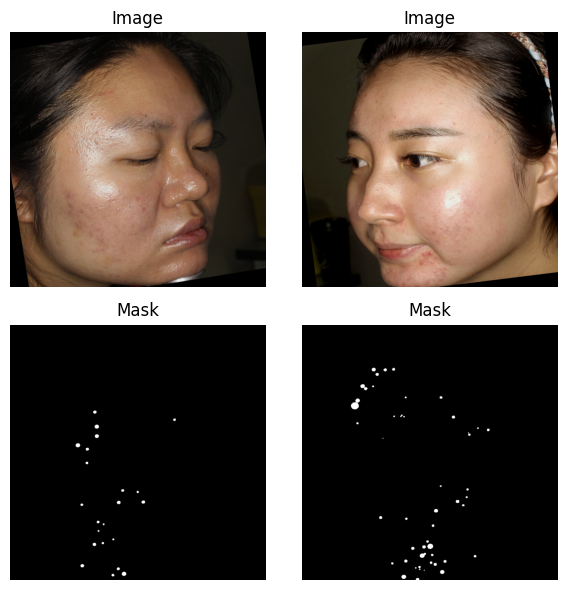

In [9]:
def denormalize_image(img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    return torch.clamp(img, 0, 1)


def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))
    batch_size = imgs.shape[0]

    fig, axes = plt.subplots(2, batch_size, figsize=(3 * batch_size, 6))
    if batch_size == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(batch_size):
        img = denormalize_image(imgs[i]).permute(1, 2, 0).numpy()
        mask = masks[i, 0].numpy()

        axes[0, i].imshow(img)
        axes[0, i].set_title('Image')
        axes[0, i].axis('off')

        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title('Mask')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


show_batch_with_masks(train_loader)

## **Model**

In [10]:
class SegFormerBinary(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.1):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True,
        )

        if hasattr(self.model.decode_head, 'dropout'):
            self.model.decode_head.dropout.p = dropout

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode='bilinear',
            align_corners=False,
        )
        return logits


model = SegFormerBinary(model_name=MODEL_NAME, dropout=0.1).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8,
    T_mult=1,
    eta_min=1e-6,
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler('cuda') if use_amp else None

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

## **Loss Function**

In [12]:
class SoftDiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * intersection + self.eps) / (denominator + self.eps)
        return 1 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()
dice_loss = SoftDiceLoss()


def loss_fn(logits, targets):
    return 0.5 * bce_loss(logits, targets.float()) + 0.5 * dice_loss(logits, targets)
    

@torch.no_grad()
def dice_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    denominator = preds.sum(dim=1) + targets.sum(dim=1)

    return ((2 * intersection + eps) / (denominator + eps)).mean()


@torch.no_grad()
def iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    return ((intersection + eps) / (union + eps)).mean()


def get_non_black_mask_from_normalized(imgs, threshold=0.03):
    mean = torch.tensor(IMAGENET_MEAN, device=imgs.device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=imgs.device).view(1, 3, 1, 1)
    imgs_denorm = (imgs * std + mean).clamp(0, 1)
    return (imgs_denorm > threshold).any(dim=1, keepdim=True).float()


@torch.no_grad()
def evaluate_segmentation_metrics(model, loader, device, threshold=0.5, black_threshold=0.03, eps=1e-8):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).float()

        logits = model(imgs)
        preds = (torch.sigmoid(logits) > threshold).float()
        valid_mask = get_non_black_mask_from_normalized(imgs, threshold=black_threshold)

        preds = preds * valid_mask
        masks = masks * valid_mask

        total_tp += (preds * masks).sum().item()
        total_fp += (preds * (1 - masks) * valid_mask).sum().item()
        total_fn += ((1 - preds) * masks * valid_mask).sum().item()
        total_tn += ((1 - preds) * (1 - masks) * valid_mask).sum().item()

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'dice': dice,
    }

## **Training**

In [13]:
def train_one_epoch(model, loader, optimizer, device, scaler=None):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    n = 0
    amp_enabled = scaler is not None and device.type == 'cuda'

    progress = tqdm(loader, desc='Training', leave=False)
    for imgs, masks in progress:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss = loss_fn(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = imgs.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice_from_logits(logits.detach(), masks).item() * batch_size
        n += batch_size

        progress.set_postfix(loss=total_loss / n, dice=total_dice / n)

    return {'loss': total_loss / n, 'dice': total_dice / n}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n = 0
    amp_enabled = device.type == 'cuda'

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss = loss_fn(logits, masks)

        batch_size = imgs.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice_from_logits(logits, masks).item() * batch_size
        total_iou += iou_from_logits(logits, masks).item() * batch_size
        n += batch_size

    return {
        'loss': total_loss / n,
        'dice': total_dice / n,
        'iou': total_iou / n,
    }

## **Run Training**

In [ ]:
gc.collect()
torch.cuda.empty_cache()

best_dice = -1.0
history = {
    'epoch': [],
    'train_loss': [],
    'train_dice': [],
    'val_loss': [],
    'val_dice': [],
    'val_iou': [],
    'lr': [],
}

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device, scaler=scaler)
    val_metrics = evaluate(model, val_loader, device)
    lr = optimizer.param_groups[0]['lr']

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_metrics['loss'])
    history['train_dice'].append(train_metrics['dice'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_dice'].append(val_metrics['dice'])
    history['val_iou'].append(val_metrics['iou'])
    history['lr'].append(lr)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_dice={val_metrics['dice']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | "
        f"lr={lr:.6f}"
    )

    if val_metrics['dice'] > best_dice:
        best_dice = val_metrics['dice']
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f'  -> saved best model, val_dice={best_dice:.4f}')

    scheduler.step()

Training:  27%|██▋       | 128/482 [01:47<04:11,  1.41it/s, dice=0.217, loss=0.655] 

## **Training Curves**

In [ ]:
def plot_history(history):
    epochs = history['epoch']

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_dice'], label='Train Dice')
    plt.plot(epochs, history['val_dice'], label='Val Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.title('Dice Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_history(history)

## **Evaluation**

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

test_metrics = evaluate_segmentation_metrics(model, test_loader, device, threshold=THRESHOLD)
print(test_metrics)

## **Predictions Visualization**

In [ ]:
def compute_metrics_single(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)
    return dice, iou


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def get_valid_non_black_mask_np(img, threshold=0.03):
    return (img > threshold).any(axis=2)


@torch.no_grad()
def get_predictions(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device, non_blocking=True)
    masks = masks.to(device, non_blocking=True).float()

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), probs.cpu(), preds.cpu()


def visualize_predictions_grid(imgs, masks, preds, n=4, black_threshold=0.03):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = denormalize_image(imgs[i]).permute(1, 2, 0).numpy()
        gt = masks[i, 0].numpy()
        pred = preds[i, 0].numpy()

        valid_mask = get_valid_non_black_mask_np(img, threshold=black_threshold)
        gt_valid = gt * valid_mask
        pred_valid = pred * valid_mask

        dice, iou = compute_metrics_single(pred_valid, gt_valid)
        overlay = make_error_overlay(img, pred_valid, gt_valid, alpha=0.45)

        gt_show = gt.copy()
        pred_show = pred.copy()
        gt_show[~valid_mask] = 0
        pred_show[~valid_mask] = 0

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_show, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_show, cmap='gray')
        axes[i, 2].set_title(f'Prediction\nDice={dice:.3f}  IoU={iou:.3f}')
        axes[i, 2].axis('off')

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay\nGreen=TP  Red=FP  Blue=FN')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()


imgs, masks, probs, preds = get_predictions(model, test_loader, device, threshold=THRESHOLD)
visualize_predictions_grid(imgs, masks, preds, n=10)